#### Importing Libraries

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as

In [ ]:
 plt
import seaborn as sns

sns.set(style="whitegrid")

#### Dataset Loading

In [3]:
df = pd.read_csv(r"C:\Users\HP\EcoVision-CO2-Analytics\data\owid-co2-data.csv")
df.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1850,AFG,3752993.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1851,AFG,3767956.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.165,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,Afghanistan,1852,AFG,3783940.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.164,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
3,Afghanistan,1853,AFG,3800954.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.164,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
4,Afghanistan,1854,AFG,3818038.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.163,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


#### Data Cleaning

In [4]:
df = df[['country', 'year', 'co2', 'population', 'gdp']]
df

,country,year,co2,population,gdp
0,Afghanistan,1850,NaN,3752993.0,NaN
1,Afghanistan,1851,NaN,3767956.0,NaN
2,Afghanistan,1852,NaN,3783940.0,NaN
3,Afghanistan,1853,NaN,3800954.0,NaN
4,Afghanistan,1854,NaN,3818038.0,NaN
...,...,...,...,...,...
48053,Zimbabwe,2018,10.715,15052191.0,2.271535e+10
48054,Zimbabwe,2019,9.775,15354606.0,NaN
48055,Zimbabwe,2020,7.850,15669663.0,NaN
48056,Zimbabwe,2021,8.396,15993525.0,NaN


In [5]:
df = df[df['co2'].notna()]
df

,country,year,co2,population,gdp
99,Afghanistan,1949,0.015,7356890.0,NaN
100,Afghanistan,1950,0.084,7480464.0,9.421400e+09
101,Afghanistan,1951,0.092,7571542.0,9.692280e+09
102,Afghanistan,1952,0.092,7667534.0,1.001733e+10
103,Afghanistan,1953,0.106,7764549.0,1.063052e+10
...,...,...,...,...,...
48053,Zimbabwe,2018,10.715,15052191.0,2.271535e+10
48054,Zimbabwe,2019,9.775,15354606.0,NaN
48055,Zimbabwe,2020,7.850,15669663.0,NaN
48056,Zimbabwe,2021,8.396,15993525.0,NaN


In [7]:
df['gdp'] = df['gdp'].fillna(df['gdp'].median())
df

C:\Users\HP\AppData\Local\Temp\ipykernel_17340\1472316256.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['gdp'] = df['gdp'].fillna(df['gdp'].median())


,country,year,co2,population,gdp
99,Afghanistan,1949,0.015,7356890.0,2.977647e+10
100,Afghanistan,1950,0.084,7480464.0,9.421400e+09
101,Afghanistan,1951,0.092,7571542.0,9.692280e+09
102,Afghanistan,1952,0.092,7667534.0,1.001733e+10
103,Afghanistan,1953,0.106,7764549.0,1.063052e+10
...,...,...,...,...,...
48053,Zimbabwe,2018,10.715,15052191.0,2.271535e+10
48054,Zimbabwe,2019,9.775,15354606.0,2.977647e+10
48055,Zimbabwe,2020,7.850,15669663.0,2.977647e+10
48056,Zimbabwe,2021,8.396,15993525.0,2.977647e+10


In [9]:
df['population'] = df['population'].fillna(df['population'].median())
df

C:\Users\HP\AppData\Local\Temp\ipykernel_17340\1257319617.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['population'] = df['population'].fillna(df['population'].median())


,country,year,co2,population,gdp
99,Afghanistan,1949,0.015,7356890.0,2.977647e+10
100,Afghanistan,1950,0.084,7480464.0,9.421400e+09
101,Afghanistan,1951,0.092,7571542.0,9.692280e+09
102,Afghanistan,1952,0.092,7667534.0,1.001733e+10
103,Afghanistan,1953,0.106,7764549.0,1.063052e+10
...,...,...,...,...,...
48053,Zimbabwe,2018,10.715,15052191.0,2.271535e+10
48054,Zimbabwe,2019,9.775,15354606.0,2.977647e+10
48055,Zimbabwe,2020,7.850,15669663.0,2.977647e+10
48056,Zimbabwe,2021,8.396,15993525.0,2.977647e+10


In [10]:
df = df[df['year'] >= 2000]
df

,country,year,co2,population,gdp
150,Afghanistan,2000,1.047,19542986.0,1.128379e+10
151,Afghanistan,2001,1.069,19688634.0,1.102127e+10
152,Afghanistan,2002,1.341,21000258.0,1.880487e+10
153,Afghanistan,2003,1.560,22645136.0,2.107434e+10
154,Afghanistan,2004,1.237,23553554.0,2.233257e+10
...,...,...,...,...,...
48053,Zimbabwe,2018,10.715,15052191.0,2.271535e+10
48054,Zimbabwe,2019,9.775,15354606.0,2.977647e+10
48055,Zimbabwe,2020,7.850,15669663.0,2.977647e+10
48056,Zimbabwe,2021,8.396,15993525.0,2.977647e+10


In [11]:
print(df.shape)
df.info()

(5593, 5)
<class 'pandas.core.frame.DataFrame'>
Index: 5593 entries, 150 to 48057
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     5593 non-null   object 
 1   year        5593 non-null   int64  
 2   co2         5593 non-null   float64
 3   population  5593 non-null   float64
 4   gdp         5593 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 262.2+ KB


In [13]:
df['co2_per_capita'] = df['co2'] / df['population']
df

C:\Users\HP\AppData\Local\Temp\ipykernel_17340\384124884.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['co2_per_capita'] = df['co2'] / df['population']


,country,year,co2,population,gdp,co2_per_capita
150,Afghanistan,2000,1.047,19542986.0,1.128379e+10,5.357421e-08
151,Afghanistan,2001,1.069,19688634.0,1.102127e+10,5.429529e-08
152,Afghanistan,2002,1.341,21000258.0,1.880487e+10,6.385636e-08
153,Afghanistan,2003,1.560,22645136.0,2.107434e+10,6.888897e-08
154,Afghanistan,2004,1.237,23553554.0,2.233257e+10,5.251861e-08
...,...,...,...,...,...,...
48053,Zimbabwe,2018,10.715,15052191.0,2.271535e+10,7.118565e-07
48054,Zimbabwe,2019,9.775,15354606.0,2.977647e+10,6.366168e-07
48055,Zimbabwe,2020,7.850,15669663.0,2.977647e+10,5.009680e-07
48056,Zimbabwe,2021,8.396,15993525.0,2.977647e+10,5.249624e-07


##  Exploratory Data Analysis

#### **# PROBLEM 1: Which countries contribute the most CO2 emissions?**

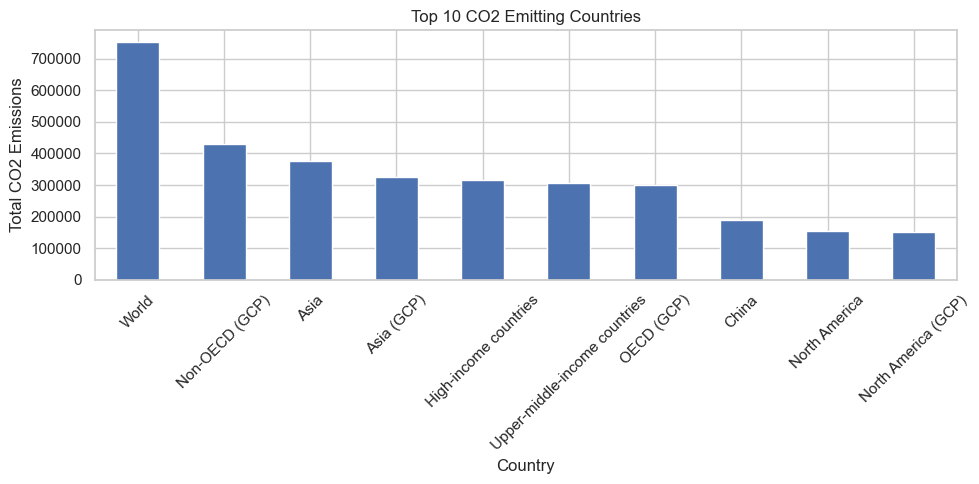

In [21]:
import os
os.makedirs("images", exist_ok=True)   

top10 = df.groupby('country')['co2'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top10.plot(kind='bar')

plt.title("Top 10 CO2 Emitting Countries")
plt.xlabel("Country")
plt.ylabel("Total CO2 Emissions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("images/top_co2_countries.png", bbox_inches='tight')  # save
plt.show()

#### **# PROBLEM 2: How have global CO2 emissions changed over time?**

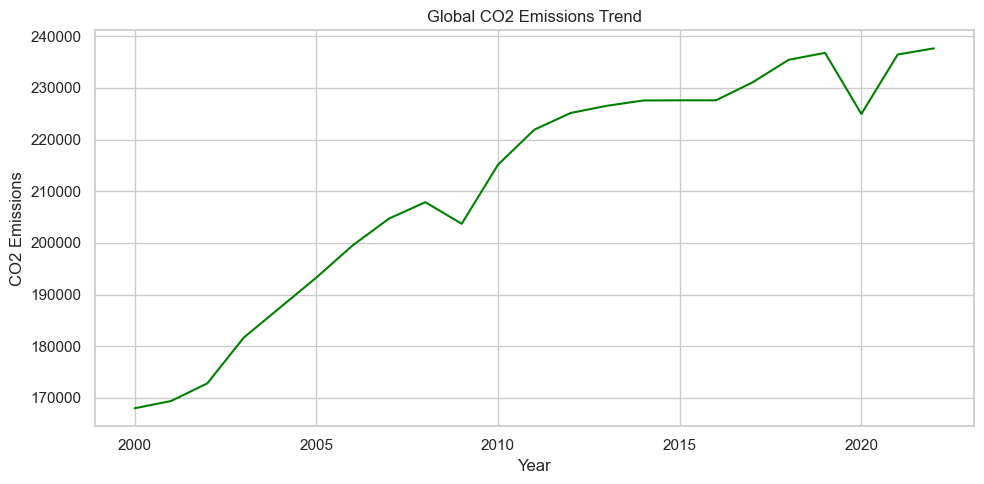

In [22]:
global_trend = df.groupby('year')['co2'].sum()

plt.figure(figsize=(10,5))
global_trend.plot(color='green')

plt.title("Global CO2 Emissions Trend")
plt.xlabel("Year")
plt.ylabel("CO2 Emissions")

plt.tight_layout()
plt.savefig("images/global_co2_trend.png", bbox_inches='tight')
plt.show()


#### **# PROBLEM 3: Are emission trends similar across top countries?**

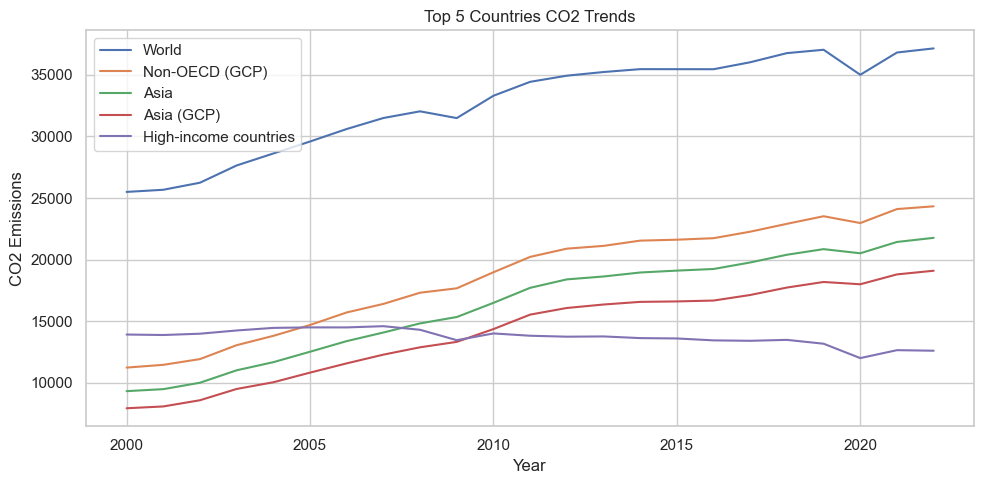

In [23]:
top5 = top10.head(5).index

plt.figure(figsize=(10,5))
for country in top5:
    subset = df[df['country'] == country]
    plt.plot(subset['year'], subset['co2'], label=country)

plt.legend()
plt.title("Top 5 Countries CO2 Trends")
plt.xlabel("Year")
plt.ylabel("CO2 Emissions")

plt.tight_layout()
plt.savefig("images/top5_country_trends.png", bbox_inches='tight')
plt.show()

#### **# PROBLEM 4: Does economic growth influence emissions?**

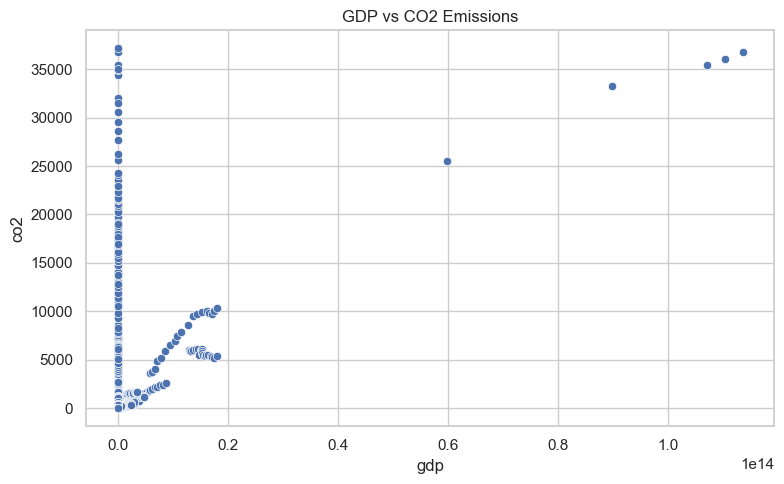

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='gdp', y='co2', data=df)

plt.title("GDP vs CO2 Emissions")

plt.tight_layout()
plt.savefig("images/gdp_vs_co2.png", bbox_inches='tight')
plt.show()

#### **# PROBLEM 5: Does population impact emissions?**

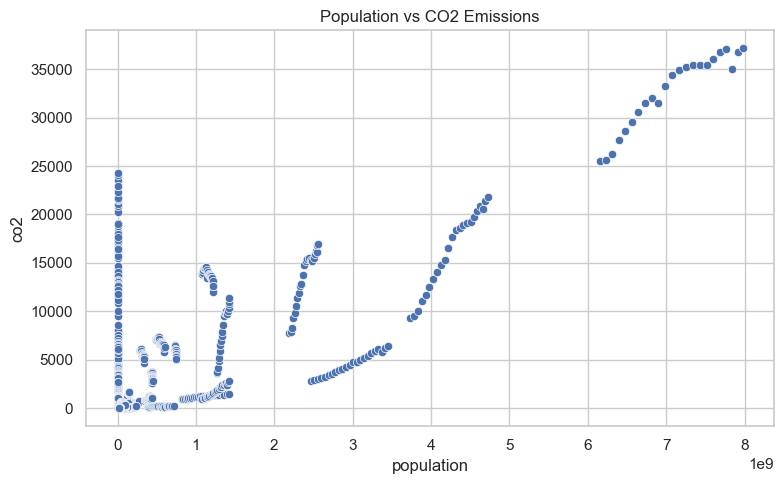

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='population', y='co2', data=df)

plt.title("Population vs CO2 Emissions")

plt.tight_layout()
plt.savefig("images/population_vs_co2.png", bbox_inches='tight')
plt.show()

#### **# PROBLEM 6: What factors are most correlated with CO2?**

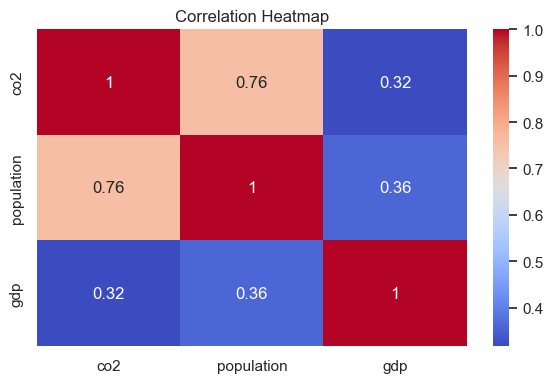

In [26]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['co2','population','gdp']].corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("images/correlation_heatmap.png", bbox_inches='tight')
plt.show()

#### **# PROBLEM 7: Are emissions evenly distributed?**

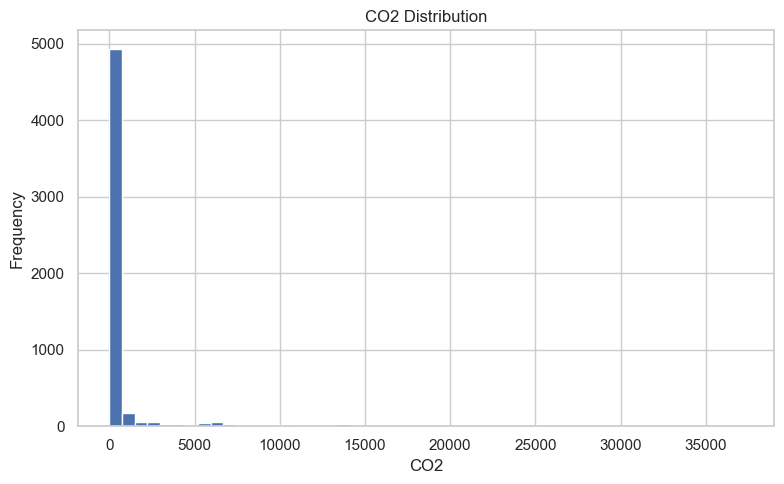

In [27]:
plt.figure(figsize=(8,5))
plt.hist(df['co2'], bins=50)

plt.title("CO2 Distribution")
plt.xlabel("CO2")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("images/co2_distribution.png", bbox_inches='tight')
plt.show()

#### **# PROBLEM 8: Are there extreme emission outliers?**

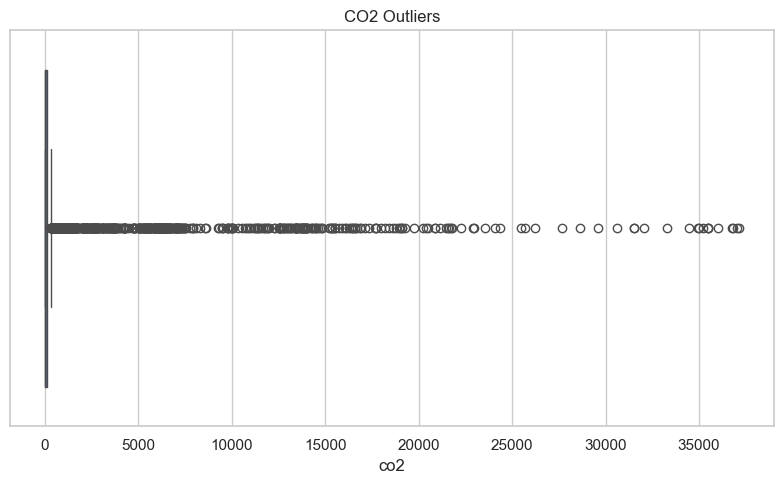

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['co2'])

plt.title("CO2 Outliers")

plt.tight_layout()
plt.savefig("images/co2_outliers.png", bbox_inches='tight')
plt.show()


#### **# PROBLEM 9: Is average emission increasing globally?**

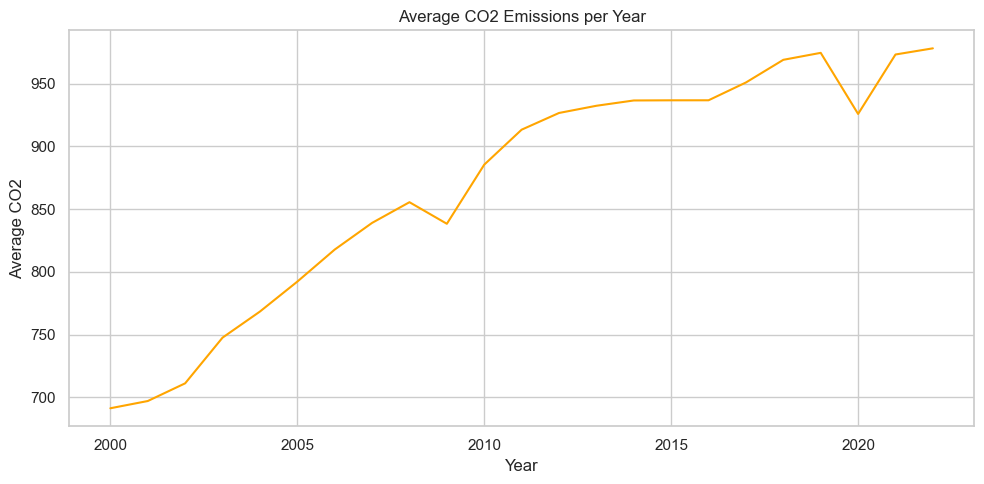

In [31]:
avg_co2 = df.groupby('year')['co2'].mean()

plt.figure(figsize=(10,5))
avg_co2.plot(color='orange')

plt.title("Average CO2 Emissions per Year")
plt.xlabel("Year")
plt.ylabel("Average CO2")

plt.tight_layout()
plt.savefig("images/avg_co2_trend.png", bbox_inches='tight')
plt.show()

#### **# PROBLEM 10: What share of emissions comes from top countries?**

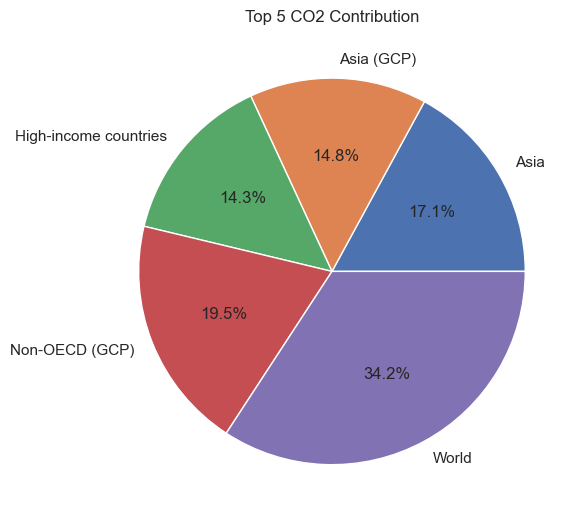

In [32]:
top5_sum = df[df['country'].isin(top5)].groupby('country')['co2'].sum()

plt.figure(figsize=(6,6))
top5_sum.plot(kind='pie', autopct='%1.1f%%')

plt.title("Top 5 CO2 Contribution")
plt.ylabel('')

plt.tight_layout()
plt.savefig("images/top5_contribution.png", bbox_inches='tight')
plt.show()